# Inclusive OR vs. Exclusive OR (XOR)

Two connectives that agree almost everywhere, and the ONE case where they
don't is the entire reason two different words (and two different
symbols) exist for them.

In [1]:
import itertools
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

try:
    from matplotlib_venn import venn2
    HAVE_VENN = True
except ImportError:
    HAVE_VENN = False

print(f"matplotlib_venn available: {HAVE_VENN} "
      f"(if False, the Venn cell below falls back to a manual circle drawing)")

matplotlib_venn available: False (if False, the Venn cell below falls back to a manual circle drawing)


## 1. The truth tables, side by side

The only row where they disagree: **A=1, B=1**.

In [2]:
print(f"{'A':>3} {'B':>3} | {'A OR B (inclusive)':>19} {'A XOR B (exclusive)':>20}")
for a, b in itertools.product([0, 1], repeat=2):
    inclusive = a | b
    exclusive = a ^ b
    flag = "  <-- the ONLY disagreement" if a == 1 and b == 1 else ""
    print(f"{a:>3} {b:>3} | {inclusive:>19} {exclusive:>20}{flag}")

  A   B |  A OR B (inclusive)  A XOR B (exclusive)
  0   0 |                   0                    0
  0   1 |                   1                    1
  1   0 |                   1                    1
  1   1 |                   1                    0  <-- the ONLY disagreement


## 2. Why "exclusive" -- drawn, not just stated

Inclusive OR is the Venn-diagram **union** ($A\cup B$): everything in
either circle, INCLUDING the overlap. Exclusive OR is the **symmetric
difference** ($A\triangle B = (A\cup B)\setminus(A\cap B)$): the union
with the overlap carved back OUT -- literally EXCLUDED. That single
carved-out region is the etymology of the word "exclusive.\"

matplotlib_venn not installed; drawing manually with plain circles instead


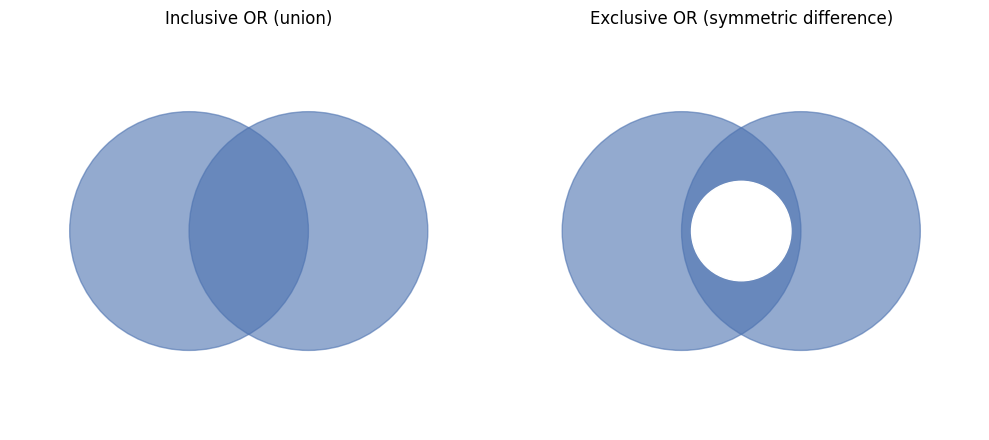

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

if HAVE_VENN:
    plt.sca(axes[0])
    v1 = venn2(subsets=(1, 1, 1), set_labels=('A', 'B'))
    for region_id in ('10', '01', '11'):
        if v1.get_patch_by_id(region_id):
            v1.get_patch_by_id(region_id).set_color('#4c72b0')
            v1.get_patch_by_id(region_id).set_alpha(0.6)
    axes[0].set_title('Inclusive OR: A union B\n(overlap INCLUDED)')

    plt.sca(axes[1])
    v2 = venn2(subsets=(1, 1, 1), set_labels=('A', 'B'))
    for region_id in ('10', '01'):
        if v2.get_patch_by_id(region_id):
            v2.get_patch_by_id(region_id).set_color('#dd8452')
            v2.get_patch_by_id(region_id).set_alpha(0.6)
    if v2.get_patch_by_id('11'):
        v2.get_patch_by_id('11').set_color('white')
        v2.get_patch_by_id('11').set_alpha(1.0)
    axes[1].set_title('Exclusive OR (XOR): symmetric difference\n(overlap EXCLUDED -- carved back out)')
else:
    print("matplotlib_venn not installed; drawing manually with plain circles instead")
    for ax, title, exclude_overlap in [(axes[0], 'Inclusive OR (union)', False),
                                         (axes[1], 'Exclusive OR (symmetric difference)', True)]:
        c1 = plt.Circle((-0.3, 0), 0.6, color='#4c72b0', alpha=0.6)
        c2 = plt.Circle((0.3, 0), 0.6, color='#4c72b0', alpha=0.6)
        ax.add_patch(c1); ax.add_patch(c2)
        if exclude_overlap:
            overlap = plt.Circle((0, 0), 0.25, color='white')
            ax.add_patch(overlap)
        ax.set_xlim(-1.2, 1.2); ax.set_ylim(-1, 1); ax.set_aspect('equal')
        ax.set_title(title); ax.axis('off')

plt.tight_layout()
plt.show()

## 3. Two different symbols, two different histories

**Math**: XOR is written $A\oplus B$ (circled plus) because XOR really
IS addition, in the field $\mathrm{GF}(2)=\{0,1\}$ where you drop the
carry -- $1\oplus1=0$ is exactly $1+1=2\equiv 0\pmod 2$. The $\oplus$
symbol is a deliberate, meaningful choice: it says "this is addition,
just in a 2-element number system," verified below.

**Programming (C, and everything descended from it -- Python, Java,
...)**: bitwise XOR is written `^` (caret). This is NOT a deep
mathematical choice -- `&` was already claimed for AND and `|` for OR
when C's operators were designed, and `^` was simply one of the few
remaining, rarely-used ASCII symbols available on a keyboard. The
caret's XOR meaning is a naming-slot-availability artifact of 1970s
keyboard layouts, not a statement about what XOR "is" the way $\oplus$
is.

In [4]:
a, b = sp.symbols('a b')
# XOR as addition mod 2: verify for all 4 truth-table rows
for av, bv in itertools.product([0, 1], repeat=2):
    xor_result = av ^ bv
    mod2_result = (av + bv) % 2
    print(f"{av} XOR {bv} = {xor_result}   ({av}+{bv}) mod 2 = {mod2_result}   match: {xor_result == mod2_result}")

0 XOR 0 = 0   (0+0) mod 2 = 0   match: True
0 XOR 1 = 1   (0+1) mod 2 = 1   match: True
1 XOR 0 = 1   (1+0) mod 2 = 1   match: True
1 XOR 1 = 0   (1+1) mod 2 = 0   match: True


## 4. The computer-engineering <-> quantum-mechanics connection: CNOT *is* XOR

The quantum CNOT gate (Controlled-NOT, one of the fundamental 2-qubit
gates in every quantum computer) is defined to flip its target qubit
exactly when the control qubit is $|1\rangle$. Restricted to the
computational basis states $|00\rangle,|01\rangle,|10\rangle,|11\rangle$,
this is EXACTLY classical XOR: `target_out = control XOR target_in`.
Verified below with the real $4\times4$ CNOT unitary matrix, not assumed.

In [5]:
CNOT = np.array([
    [1, 0, 0, 0],
    [0, 1, 0, 0],
    [0, 0, 0, 1],
    [0, 0, 1, 0],
], dtype=float)

basis_labels = ['00', '01', '10', '11']
print(f"{'input |control,target>':>24} -> {'CNOT output':>12}   {'classical control XOR target':>29}")
all_match = True
for i, label in enumerate(basis_labels):
    control, target = int(label[0]), int(label[1])
    out_vec = CNOT @ np.eye(4)[i]
    out_label = basis_labels[np.argmax(out_vec)]
    classical_xor = control ^ target
    match = int(out_label[1]) == classical_xor and int(out_label[0]) == control
    all_match &= match
    print(f"{'|' + label + '>':>24} -> {'|' + out_label + '>':>12}   "
          f"control={control} XOR target={target} = {classical_xor}   match: {match}")

assert all_match
print("\nCNOT is a REVERSIBLE (unitary) gate -- unlike classical XOR alone, you can always")
print("undo it (apply CNOT twice = identity). This is WHY quantum computing needs gates")
print("like CNOT rather than plain classical XOR: quantum evolution must be reversible,")
print("and CNOT is the simplest reversible gate that still reduces to ordinary XOR")
print("whenever you only look at computational-basis (classical-looking) inputs.")

# bonus: confirm CNOT really is its own inverse (unitary + self-inverse here)
identity_check = CNOT @ CNOT
print(f"\nCNOT @ CNOT == identity: {np.allclose(identity_check, np.eye(4))}")

  input |control,target> ->  CNOT output    classical control XOR target
                    |00> ->         |00>   control=0 XOR target=0 = 0   match: True
                    |01> ->         |01>   control=0 XOR target=1 = 1   match: True
                    |10> ->         |11>   control=1 XOR target=0 = 1   match: True
                    |11> ->         |10>   control=1 XOR target=1 = 0   match: True

CNOT is a REVERSIBLE (unitary) gate -- unlike classical XOR alone, you can always
undo it (apply CNOT twice = identity). This is WHY quantum computing needs gates
like CNOT rather than plain classical XOR: quantum evolution must be reversible,
and CNOT is the simplest reversible gate that still reduces to ordinary XOR
whenever you only look at computational-basis (classical-looking) inputs.

CNOT @ CNOT == identity: True


## Summary

| | Inclusive OR | Exclusive OR (XOR) |
|---|---|---|
| Venn diagram | union $A\cup B$ | symmetric difference $A\triangle B$ |
| Disagreement | true when both true | **false** when both true -- the excluded case |
| Math symbol | $\vee$ | $\oplus$ (addition mod 2, GF(2)) |
| C/Python/Java symbol | `\|` | `^` (keyboard-availability artifact, not deeply meaningful) |
| Quantum computing | -- | CNOT gate, restricted to basis states, IS exactly XOR -- made reversible |